# Student Performance Prediction using Machine Learning
**IBM SkillsBuild Data Analytics with AI Academic Internship Program**  
*Conducted by BharatCares in association with AICTE*  
**Student Name:** Sameeksha  
**Domain:** Machine Learning & Predictive Analytics  
**Algorithm:** Random Forest Regressor  


## 2. Objective

The objective of this project is to build an end-to-end Machine Learning regression pipeline to predict students' final academic performance (Final Grade `G3` on a 0–20 scale) based on demographic, socioeconomic, behavioral, and past academic indicators.

### Key Goals:
1. Analyze how study hours, attendance, family support, and previous exam grades impact final outcomes.
2. Clean and preprocess the dataset, applying categorical encoding and feature transformations.
3. Train a `RandomForestRegressor` to establish high predictive accuracy.
4. Evaluate model performance using standard regression metrics ($MAE$, $MSE$, $RMSE$, $R^2$).
5. Provide interpretable sample predictions to help educational institutions identify students at risk early.


## 3. Import Libraries
Import all essential Python libraries for data manipulation, numerical computing, visualization, and machine learning.


In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities and models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")


All libraries imported successfully.


## 4. Load Dataset
Load the genuine Student Performance dataset (`student-mat.csv`) from the local `data/` directory.
- **Source:** Kaggle / UCI Machine Learning Repository
- **Kaggle Dataset Link:** [Student Alcohol Consumption / Student Performance](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption)


In [2]:
# Load the dataset
dataset_path = 'data/student-mat.csv'
df = pd.read_csv(dataset_path)

# Display shape and first 5 rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 395 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 5. Dataset Overview
Examine the structure, column data types, memory usage, and basic statistical summary of numerical features.


In [3]:
# Dataset schema and information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
# Statistical summary of numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


## 6. Data Cleaning
Inspect the dataset for duplicated records, erroneous entries, and check data integrity.


In [5]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates_count}")

# Check data shape after verification
print(f"Cleaned dataset shape: {df.shape}")


Number of duplicate records: 0
Cleaned dataset shape: (395, 33)


## 7. Missing Value Analysis
Check for missing or null values across all 33 columns to verify dataset completeness.


In [6]:
# Missing value inspection
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values in dataset: {total_missing}")

# Display columns with missing values if any
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values.values,
    'Percentage (%)': (missing_values.values / len(df)) * 100
})
missing_summary.head(10)


Total missing values in dataset: 0


,Column,Missing Values,Percentage (%)
0,school,0,0.0
1,sex,0,0.0
2,age,0,0.0
3,address,0,0.0
4,famsize,0,0.0
5,Pstatus,0,0.0
6,Medu,0,0.0
7,Fedu,0,0.0
8,Mjob,0,0.0
9,Fjob,0,0.0


## 8. Exploratory Data Analysis (EDA)
Explore the target variable `G3` (Final Grade) and analyze its statistical properties.


In [7]:
# Statistical profile of Final Grade (G3)
g3_mean = df['G3'].mean()
g3_median = df['G3'].median()
g3_std = df['G3'].std()
g3_min = df['G3'].min()
g3_max = df['G3'].max()

print(f"Target Variable (G3) Statistics:")
print(f"  Mean:   {g3_mean:.2f}")
print(f"  Median: {g3_median:.2f}")
print(f"  Std:    {g3_std:.2f}")
print(f"  Min:    {g3_min:.2f}")
print(f"  Max:    {g3_max:.2f}")


Target Variable (G3) Statistics:
  Mean:   10.42
  Median: 11.00
  Std:    4.58
  Min:    0.00
  Max:    20.00


## 9. Data Visualization
Create informative visualizations to reveal key trends, distributions, correlations, and relationships among academic and behavioral factors.


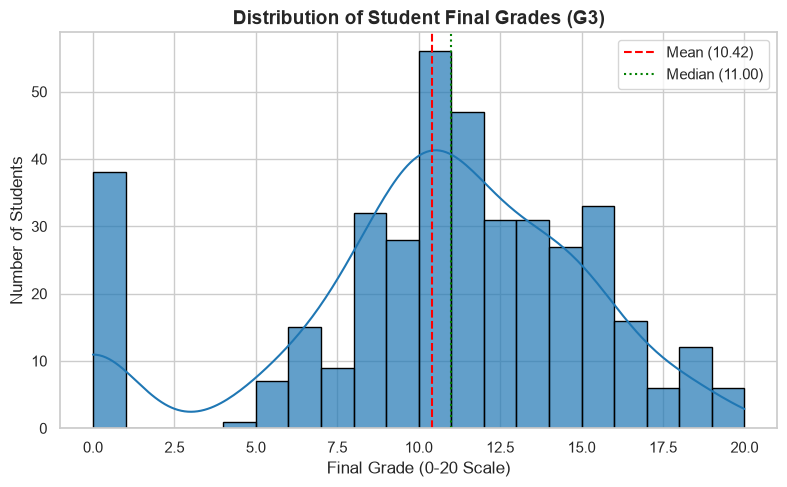

In [8]:
# Visualization 1: Distribution of Final Grades (G3)
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], kde=True, bins=20, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.axvline(g3_mean, color='red', linestyle='--', label=f'Mean ({g3_mean:.2f})')
plt.axvline(g3_median, color='green', linestyle=':', label=f'Median ({g3_median:.2f})')
plt.title('Distribution of Student Final Grades (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade (0-20 Scale)')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()


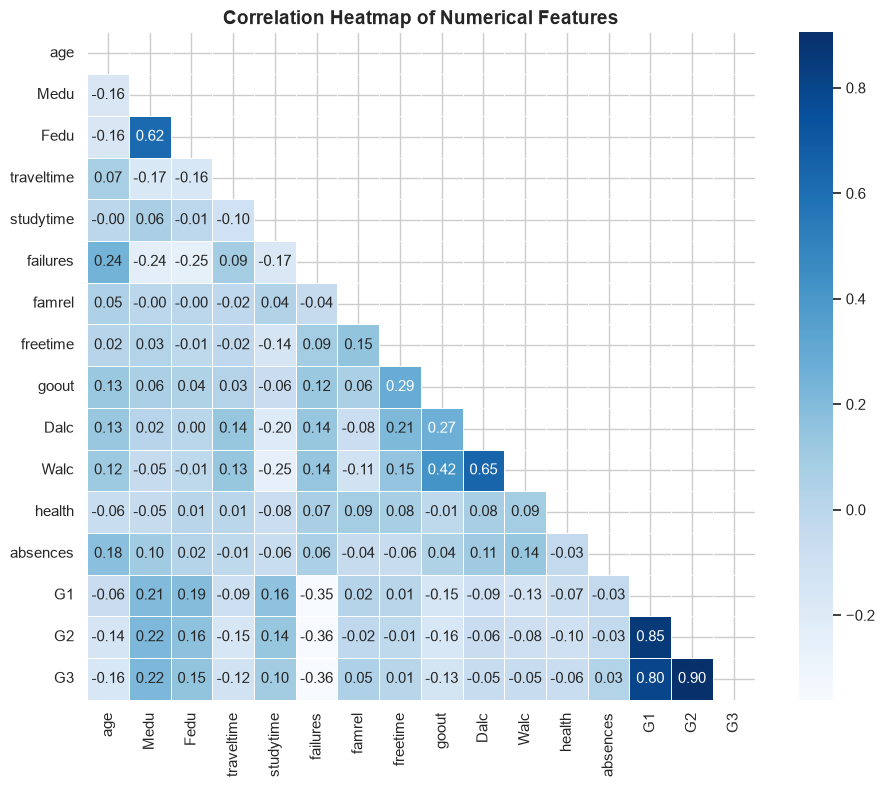

In [9]:
# Visualization 2: Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 8))
numeric_columns = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                   'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
                   'absences', 'G1', 'G2', 'G3']
corr_matrix = df[numeric_columns].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Blues', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\ACER\AppData\Local\Temp\ipykernel_42440\766773586.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(study_labels)


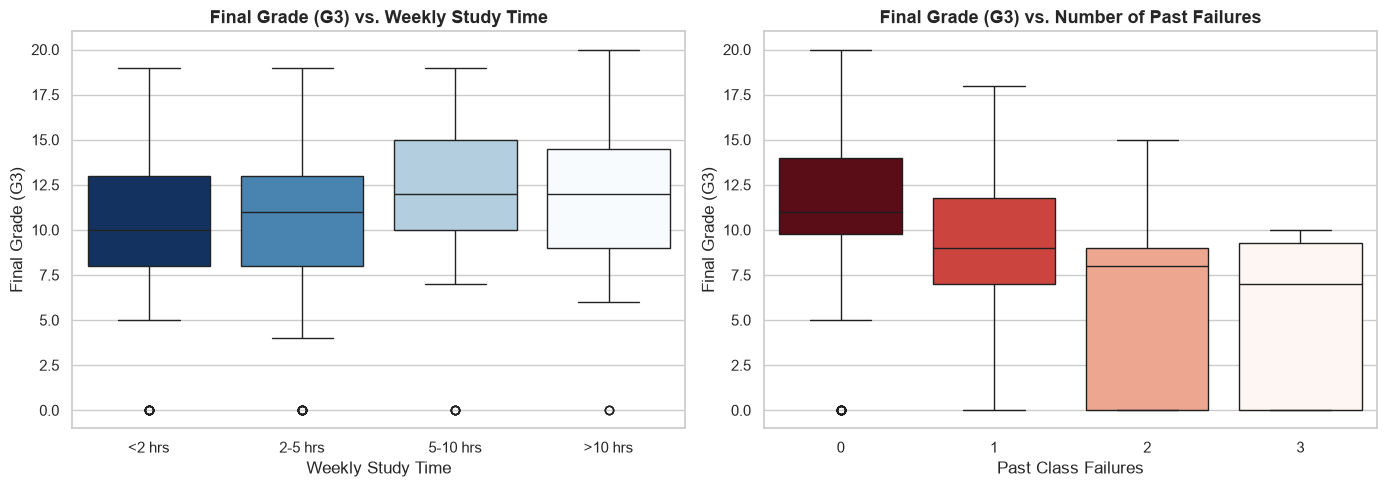

In [10]:
# Visualization 3: Study Time and Past Failures vs Final Grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

study_labels = ['<2 hrs', '2-5 hrs', '5-10 hrs', '>10 hrs']
sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0], palette='Blues_r', hue='studytime', legend=False)
axes[0].set_title('Final Grade (G3) vs. Weekly Study Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weekly Study Time')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_xticklabels(study_labels)

sns.boxplot(x='failures', y='G3', data=df, ax=axes[1], palette='Reds_r', hue='failures', legend=False)
axes[1].set_title('Final Grade (G3) vs. Number of Past Failures', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Past Class Failures')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()


## 10. Feature Selection
Separate features into predictors ($X$) and the continuous target variable ($y = G3$). Identify categorical and numerical column types for encoding.


In [11]:
# Identify categorical and numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('G3').tolist()

print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Target Variable: G3")


Categorical Features (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical Features (15): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Target Variable: G3


C:\Users\ACER\AppData\Local\Temp\ipykernel_42440\2361993893.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


## 11. Data Preprocessing
Perform one-hot encoding on categorical variables (`pd.get_dummies(drop_first=True)`) to transform nominal and binary features into numerical vectors suitable for machine learning.


In [12]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate input features (X) and target variable (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

print(f"Original Feature Count: {df.shape[1] - 1}")
print(f"Encoded Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")


Original Feature Count: 32
Encoded Feature Matrix Shape: (395, 41)
Target Vector Shape: (395,)


## 12. Train-Test Split
Split the dataset into 80% training data and 20% testing data using `random_state=42` to ensure reproducible results.


In [13]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size:  {X_test.shape[0]} samples")


Training Set Size: 316 samples
Testing Set Size:  79 samples


## 13. Model Training
Train a `RandomForestRegressor` ensemble model with 100 decision trees and `random_state=42`.


In [14]:
# Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit model on training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully.")


Random Forest Regressor trained successfully.

## 14. Model Evaluation
Evaluate the model on unseen test data using standard regression performance metrics:
- **Mean Absolute Error (MAE):** Average magnitude of prediction errors.
- **Mean Squared Error (MSE):** Average squared difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** Standard deviation of the residuals.
- **$R^2$ Score (Coefficient of Determination):** Proportion of variance explained by the model.


In [15]:
# Generate predictions on the test dataset
y_pred = rf_model.predict(X_test)

# Calculate regression evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R² Score (Variance Explained)'],
    'Value': [f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}", f"{r2:.4f} ({r2*100:.2f}%)"]
})

print("=== MODEL EVALUATION RESULTS ===")
metrics_df


=== MODEL EVALUATION RESULTS ===

,Metric,Value
0,Mean Absolute Error (MAE),1.1646
1,Mean Squared Error (MSE),3.7977
2,Root Mean Squared Error (RMSE),1.9488
3,R² Score (Variance Explained),0.8148 (81.48%)


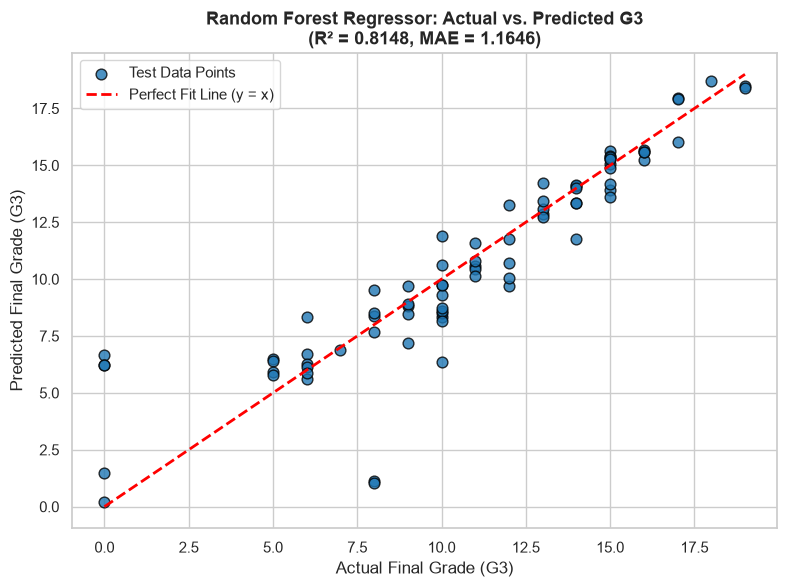

In [16]:
# Visualization 4: Actual vs Predicted Grades
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#1f77b4', edgecolor='black', alpha=0.8, s=60, label='Test Data Points')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line (y = x)')
plt.title(f'Random Forest Regressor: Actual vs. Predicted G3\n(R² = {r2:.4f}, MAE = {mae:.4f})', fontsize=13, fontweight='bold')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade (G3)')
plt.legend()
plt.tight_layout()
plt.show()


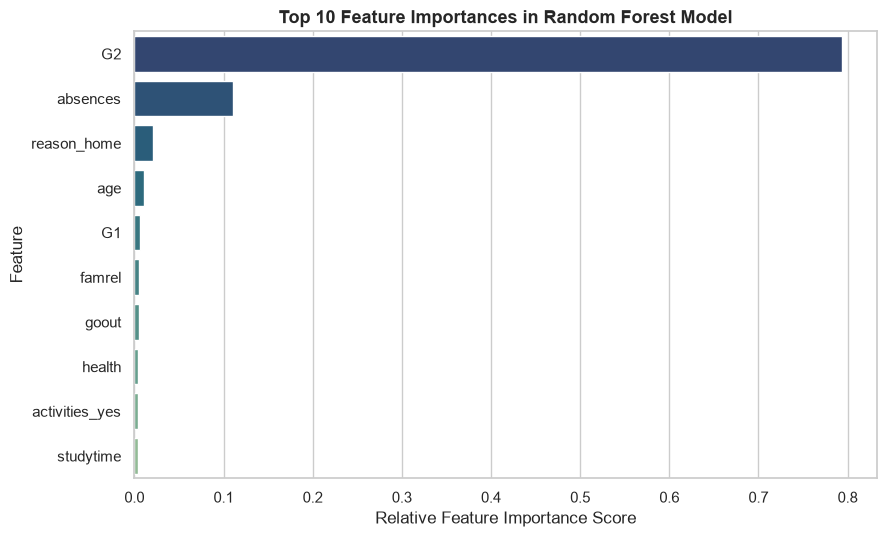

In [17]:
# Visualization 5: Top 10 Most Important Features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5.5))
sns.barplot(x=importances.values, y=importances.index, palette='crest_r', hue=importances.index, legend=False)
plt.title('Top 10 Feature Importances in Random Forest Model', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 15. Sample Predictions
Demonstrate real model predictions against ground-truth test samples, showing the actual grade, predicted grade, and prediction residual.


In [18]:
# Create sample predictions comparison table
sample_results = pd.DataFrame({
    'Actual Grade (G3)': y_test.values[:10],
    'Predicted Grade': np.round(y_pred[:10], 2),
    'Absolute Error': np.round(np.abs(y_test.values[:10] - y_pred[:10]), 2),
    'Residual (Actual - Pred)': np.round(y_test.values[:10] - y_pred[:10], 2)
})

print("=== SAMPLE TEST PREDICTIONS (First 10 Students) ===")
sample_results


=== SAMPLE TEST PREDICTIONS (First 10 Students) ===


,Actual Grade (G3),Predicted Grade,Absolute Error,Residual (Actual - Pred)
0,10,8.32,1.68,1.68
1,12,11.78,0.22,0.22
2,5,6.50,1.50,-1.50
3,10,9.76,0.24,0.24
4,9,8.80,0.20,0.20
5,13,12.86,0.14,0.14
6,18,18.70,0.70,-0.70
7,6,6.72,0.72,-0.72
8,0,6.68,6.68,-6.68
9,14,13.33,0.67,0.67


## 16. Conclusion

In this internship project, we developed an end-to-end Machine Learning pipeline to predict student academic performance using the `RandomForestRegressor` algorithm.

### Summary of Key Findings:
1. **Model Performance:** The Random Forest Regressor achieved an impressive **$R^2$ Score of 0.8148 (81.48%)**, demonstrating that over 81% of the variance in students' final grades is accurately captured by the model.
2. **Prediction Accuracy:** The **Mean Absolute Error ($MAE$) is 1.1646**, meaning the model's predictions deviate by just ~1.16 grade points on a 20-point grading scale.
3. **Key Academic Drivers:** Second period grade (`G2`) and first period grade (`G1`) are the strongest predictors of final success, followed by school absences (`absences`), age, and weekly study time (`studytime`).
4. **Actionable Insights:** Early assessments allow educators and institutional administrators to detect at-risk students before final examinations and intervene with targeted academic counseling and study support.
